# 24: the embedded footprint

The streaming filter's claim to run on a microcontroller rests on three
separate things: the state it must keep resident (the number that has to
fit in SRAM), what a hand-flashed struct actually measures against the
model of that state, and the per-step cost on a desktop as a stand-in for
the algorithm's shape rather than a prediction of MCU cycles.

Claims:

1. The filter's resident state is a fixed-size struct that does not grow
   with the stream: it depends on the window and the parameter count, not
   on how many samples have passed. False if a live filter's buffers are a
   different size after 10,000 samples than after 100.
2. The struct-size model (`cost.embedded_footprint`) predicts the flashed
   device's size to a difference the reading can name in full, not a
   residual. False if a gap remains that the reading cannot attribute to
   named fields.
3. On this desktop, a naive sliding-window refit and the streaming filters
   cost the same order of magnitude a step once the refit is charged for
   the step it fits on, and the plain Kalman-CA baseline is the cheapest
   per axis. False if the refit and the filters differ by much more than a
   small factor, or if the one-axis Kalman baseline is not the fastest.
4. The resident state grows linearly with window size and quadratically
   with parameter count. False if the sweep does not show that shape.
5. A three-axis tracker at W=15, the configuration section 1 sizes, sits
   under half the SRAM of every named MCU class, and the compute estimate
   for one 10 Hz epoch, scaled by the error it shows at the one point
   where a chip was timed, stays under the budget on every part with a
   32-bit core. False if either bound is crossed. The same three axes at a
   60-sample window are a fit but not a margin on the 2 KB part, and the
   scaled estimate puts that part over a 10 Hz epoch; section 5 prints
   both without claiming them.

Section 3 points at notebook 21 for the filter's own tuning and step cost
on its native jobs; this notebook takes the filter as given and asks only
whether it fits and what it costs beside the alternatives. Section 2
points at the rig notebook (`packages/dtfit-hardware`) for the flashed
capture this section's model is checked against; nothing here reads
anything under `packages/dtfit-hardware`.

In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit.streaming import ImageFilter

from dtfit_experimental.study import baselines, cost, notebook, plants

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

REPEATS = 1 if QUICK else 5
PLANT_SET = [plants.PLANTS[0]] if QUICK else plants.PLANTS
print(f"QUICK={QUICK} REPEATS={REPEATS} plants={[p['key'] for p in PLANT_SET]}")


def median_spread(values):
    """``(median, low, high)`` of a small sample, the spread a timing claim
    reports beside its median instead of a single number."""
    v = sorted(values)
    return float(np.median(v)), float(v[0]), float(v[-1])

QUICK=False REPEATS=5 plants=['damped_osc', 'ac_sine', 'first_order', 'ca_traj']


## The deployable struct

`cost.embedded_footprint(n_params, window)` counts the words a minimal,
no-malloc C port keeps resident between samples. Three configurations
stand in for real embedded jobs: a GPS axis tracked as a constant-
acceleration quadratic, a damped sine from a control-identification loop,
and a first-order range smoother.

In [2]:
CONFIGS = [
    ("CA quadratic (GPS axis)", 3, 15),
    ("damped sine (control ID)", 3, 50),
    ("linear (range smoother)", 2, 20),
]


def approx_flops_per_update(n, w, n_sub=2):
    """Rough FLOP count for one block-filter update with a degree-(n-1)
    polynomial model: evaluating the model and its n derivatives over the
    W-point window dominates, with the small (n_sub x n) Kalman algebra on
    top. Order-of-magnitude only, for the MCU compute sanity check in
    section 5, not a cycle count."""
    model_eval = 2 * w * n
    jac_eval = 2 * w * n * n
    integrate = 2 * w * (n + 1)
    kalman_alg = n * n * n_sub + n_sub ** 3 + n * n_sub ** 2 + n * n
    return model_eval + jac_eval + integrate + kalman_alg


rows = []
for name, n, w in CONFIGS:
    fp = cost.embedded_footprint(n, w, kind="block")
    rows.append({"config": name, "n_params": n, "window": w,
                 "sram_words": fp["sram_words"],
                 "sram_bytes_f32": fp["sram_bytes_f32"],
                 "sram_bytes_f64": fp["sram_bytes_f64"],
                 "flops_per_update": approx_flops_per_update(n, w)})
state_size = pd.DataFrame(rows)
state_size

,config,n_params,window,sram_words,sram_bytes_f32,sram_bytes_f64,flops_per_update
0,CA quadratic (GPS axis),3,15,53,212,424,527
1,damped sine (control ID),3,50,123,492,984,1647
2,linear (range smoother),2,20,56,224,448,388


In [3]:
# a live block filter's resident buffers, at 100 samples and again at
# 10,000: the claim is that they are the same size at both points
plant = plants.PLANTS[0]
rng = np.random.default_rng(0)
t_long = np.linspace(0, plant["T"], 12000)
y_long = (plant["func"](t_long, *[plant["true"][k] for k in sorted(plant["true"])])
          + rng.normal(0, 0.05, t_long.size))

live = plants.EAAd(plant)
for i in range(100):
    live.f.partial_fit(float(t_long[i]), float(y_long[i]))
state_at_100 = (len(live.f._t), live.f.P.shape, sorted(live.f.params_.keys()))
for i in range(100, 10000):
    live.f.partial_fit(float(t_long[i]), float(y_long[i]))
state_at_10000 = (len(live.f._t), live.f.P.shape, sorted(live.f.params_.keys()))
print("resident window length, covariance shape, tracked params:")
print("  at 100 samples:  ", state_at_100)
print("  at 10000 samples:", state_at_10000)

resident window length, covariance shape, tracked params:
  at 100 samples:   (60, (3, 3), ['A', 'w', 'z'])
  at 10000 samples: (60, (3, 3), ['A', 'w', 'z'])


In [4]:
# fails if a config's model disagrees with the words counted above
for name, n, w in CONFIGS:
    fp = cost.embedded_footprint(n, w, kind="block")
    row = state_size[state_size.config == name].iloc[0]
    assert fp["sram_bytes_f32"] == row.sram_bytes_f32
    assert fp["sram_bytes_f64"] == row.sram_bytes_f64
# fails if the live filter's resident state grows with the stream
assert state_at_100 == state_at_10000
print("state identical at 100 and at 10000 samples:", state_at_10000)

state identical at 100 and at 10000 samples: (60, (3, 3), ['A', 'w', 'z'])


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("24_embedded_footprint", "state_size", state_size)
    print("wrote experiments/results/24_embedded_footprint/state_size.csv")

wrote experiments/results/24_embedded_footprint/state_size.csv


## The chip cross-check

The rig's flashed struct (`dtfit_hardware/.../firmware/nano_lsi_onboard/
dtfit_lsi.h`, whose window and parameter-count constants are 15 and 2) is
`float tbuf[W], ybuf[W]; int count; bool ready; float p[N], P[N][N]`,
item by item against `cost.embedded_footprint(2, 15)`.

In [6]:
n_chip, w_chip = 2, 15
model_bytes = cost.embedded_footprint(n_chip, w_chip, kind="block")["sram_bytes_f32"]
struct_bytes = 2 * w_chip * 4 + 2 * 4 + 4 * 4 + 8
# the model's own formula (embedded_footprint's docstring): buffer(2W) +
# cov(n^2) + estimate(n) + scratch(n) + bookkeeping(8), all in words
buffer_words, cov_words, est_words, scratch_words, book_words = (
    2 * w_chip, n_chip * n_chip, n_chip, n_chip, 8)
assert (buffer_words + cov_words + est_words + scratch_words + book_words
        == model_bytes // 4)
struct_book_words = 2  # count, ready: the only bookkeeping the sketch keeps
scratch_bytes = scratch_words * 4
unused_bookkeeping_bytes = (book_words - struct_book_words) * 4
chip_crosscheck = pd.DataFrame([
    {"item": "flashed struct (tbuf+ybuf, count+ready, p, P)", "bytes": struct_bytes},
    {"item": "model (cost.embedded_footprint(2, 15))", "bytes": model_bytes},
    {"item": "difference: scratch buffer (model's scratch(n) term)", "bytes": scratch_bytes},
    {"item": "difference: unused bookkeeping words (6 of 8)", "bytes": unused_bookkeeping_bytes},
])
chip_crosscheck

,item,bytes
0,"flashed struct (tbuf+ybuf, count+ready, p, P)",152
1,"model (cost.embedded_footprint(2, 15))",184
2,difference: scratch buffer (model's scratch(n)...,8
3,difference: unused bookkeeping words (6 of 8),24


In [7]:
# fails if the model's byte count moves off 184 or the struct arithmetic off 152
assert model_bytes == 184
assert struct_bytes == 152
# fails if the named fields do not account for the whole difference
assert scratch_bytes + unused_bookkeeping_bytes == model_bytes - struct_bytes
print(f"model {model_bytes} B, flashed struct {struct_bytes} B, "
      f"difference {model_bytes - struct_bytes} B all named")

model 184 B, flashed struct 152 B, difference 32 B all named


In [8]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("24_embedded_footprint", "chip_crosscheck", chip_crosscheck)
    print("wrote experiments/results/24_embedded_footprint/chip_crosscheck.csv")

wrote experiments/results/24_embedded_footprint/chip_crosscheck.csv


The 32-byte gap is named in full. Eight of those bytes are the scratch
words the model counts as resident: its `2n` term is the estimate plus a
scratch copy of it, and the sketch keeps that scratch on the stack during
an update, with only `p[N]` in the struct. The other twenty-four are six
of the eight bookkeeping scalars the model allows for and this sketch
does not need. The rig notebook (`packages/dtfit-hardware`) is where the
flashed capture that prints 152 B is taken; this section only does the
arithmetic.

## Step cost by estimator

The five `study.plants` adapters, driven over the four plants at their
own window and parameter count, `REPEATS` repeats each (a fresh adapter
every repeat, so a filter's own warm-up does not leak across repeats).
Latency times `adapter.step` alone, past the warm-up, and is reported
three ways: the median step, the mean step and the worst step. The three
differ only for the sliding-window refit, which does its work on one step
in twenty and appends and pops on the other nineteen; the mean is its
cost a step and the median is a step that does no fitting.

In [9]:
ADAPTER_NAMES = ["EAAd", "LegAd", "EKFAd", "RLSAd", "RefitAd"]
DISPLAY_NAME = {"EAAd": "dtfit block filter", "LegAd": "dtfit Legendre filter",
                "EKFAd": "EKF (params-as-state)", "RLSAd": "RLS (AR predictor)",
                "RefitAd": "sliding-window curve_fit"}


def step_latencies(adapter, t, y, warm):
    """Per-step wall time of ``adapter.step`` alone, in microseconds, over a
    stream, past ``warm`` samples. ``study.plants.drive`` reports the median
    of the same quantity, which for an adapter that batches its work is a
    step that does none of it."""
    lat = np.empty(t.size)
    for i in range(t.size):
        t0 = time.perf_counter()
        adapter.step(float(t[i]), float(y[i]))
        lat[i] = (time.perf_counter() - t0) * 1e6
    return lat[warm:]


rows = []
lat_by_plant = {}
for plant in PLANT_SET:
    rng = np.random.default_rng(0)
    t, y, clean = plants.gen_plant(plant, rng)
    warm = plant["window"] + 15
    plant_lat = {}
    for cls_name in ADAPTER_NAMES:
        meds, means, peaks = [], [], []
        for _ in range(REPEATS):
            adapter = getattr(plants, cls_name)(plant)
            lat = step_latencies(adapter, t, y, warm)
            meds.append(float(np.median(lat)))
            means.append(float(lat.mean()))
            peaks.append(float(lat.max()))
        med, lo, hi = median_spread(meds)
        plant_lat[DISPLAY_NAME[cls_name]] = med
        rows.append({"plant": plant["key"], "estimator": DISPLAY_NAME[cls_name],
                     "n_params": len(plant["true"]), "window": plant["window"],
                     "coeff_count": (len(plant["true"]) if cls_name == "EAAd" else
                                     5 if cls_name == "LegAd" else None),
                     "latency_us_median": med, "latency_us_lo": lo,
                     "latency_us_hi": hi,
                     "latency_us_mean": float(np.median(means)),
                     "latency_us_max": float(np.median(peaks))})
    lat_by_plant[plant["key"]] = plant_lat
step_cost = pd.DataFrame(rows)
step_cost

,plant,estimator,n_params,window,coeff_count,latency_us_median,latency_us_lo,latency_us_hi,latency_us_mean,latency_us_max
0,damped_osc,dtfit block filter,3,60,3.0,97.245007,95.682000,104.849998,118.196234,308.481001
1,damped_osc,dtfit Legendre filter,3,60,5.0,97.796001,96.542994,98.416000,114.095792,339.844992
2,damped_osc,EKF (params-as-state),3,60,NaN,12.253004,12.222998,12.314005,13.255313,63.700994
3,damped_osc,RLS (AR predictor),3,60,NaN,4.589005,4.568996,4.718997,4.858843,45.346009
4,damped_osc,sliding-window curve_fit,3,60,NaN,0.191008,0.190994,0.200002,120.532488,14820.758995
5,ac_sine,dtfit block filter,3,60,3.0,76.905999,76.334996,77.788005,91.536629,278.940002
6,ac_sine,dtfit Legendre filter,3,60,5.0,76.906013,76.615994,77.616991,90.017648,325.426998
7,ac_sine,EKF (params-as-state),3,60,NaN,9.267009,9.257012,9.298004,9.828579,58.460995
8,ac_sine,RLS (AR predictor),3,60,NaN,4.559013,4.519010,4.578993,4.748634,32.832992
9,ac_sine,sliding-window curve_fit,3,60,NaN,0.190994,0.190994,0.200002,29.018793,859.993001


The same estimators at a fixed 33 Hz sampling interval (0.03 s, the rig's
own rate), a 3-parameter CA quadratic window at W=15 matching the "CA
quadratic (GPS axis)" configuration above, beside a plain constant-
acceleration Kalman-CA on one axis and on three, and an isolated
sliding-window refit call (unconstrained Levenberg-Marquardt: the bounded
solver `study.plants.RefitAd` uses for stability over a long run is a
different, much slower method, and timing it here would misstate the
naive refit's floor rather than the filter's alternative). The filter
rows are one axis, so the one-axis Kalman is the like-for-like
comparison and the three-axis row is the deliverable of sections 4 and
5.

In [10]:
DT = 0.03
N_FIXED = 700
t_fixed = np.arange(N_FIXED) * DT
true_ca = {"c0": 1.0, "c1": 2.0, "c2": 0.5}
clean_ca = true_ca["c0"] + true_ca["c1"] * t_fixed + true_ca["c2"] * t_fixed ** 2
rng = np.random.default_rng(0)
y_fixed = clean_ca + rng.normal(0, 0.05 * clean_ca.std(), N_FIXED)
warm_fixed = 15 + 15


def time_filter(basis):
    reps = []
    for _ in range(REPEATS):
        f = ImageFilter("c0 + c1*t + c2*t**2", "t", p0=[0.0, 0.0, 0.0],
                         window_size=15, order=3 if basis == "block" else 5,
                         q_diag=[1e-2, 1e-2, 1e-2], basis=basis)
        step_lats = []
        for i in range(N_FIXED):
            t0 = time.perf_counter()
            f.partial_fit(float(t_fixed[i]), float(y_fixed[i]))
            step_lats.append((time.perf_counter() - t0) * 1e6)
        reps.append(float(np.median(step_lats[warm_fixed:])))
    return median_spread(reps)


def time_kalman_ca(dim):
    reps = []
    for _ in range(REPEATS):
        kf = baselines.KalmanCA(dim=dim, dt=DT, q=1e-2, r=0.5)
        step_lats = []
        for i in range(N_FIXED):
            z = clean_ca[i] + rng.normal(0, 0.05, dim)
            t0 = time.perf_counter()
            kf.update(z)
            step_lats.append((time.perf_counter() - t0) * 1e6)
        reps.append(float(np.median(step_lats[warm_fixed:])))
    return median_spread(reps)


def time_refit():
    W = 15
    t_win = np.arange(W) * DT
    clean_win = true_ca["c0"] + true_ca["c1"] * t_win + true_ca["c2"] * t_win ** 2
    y_win = clean_win + np.random.default_rng(1).normal(0, 0.02, W)
    p0 = np.array([0.5, 1.5, 0.3])
    func = lambda t, c0, c1, c2: c0 + c1 * t + c2 * t ** 2
    reps = []
    n_calls = 10 if QUICK else 50
    for _ in range(REPEATS):
        call_lats = []
        for _ in range(n_calls):
            t0 = time.perf_counter()
            baselines.scipy_curve_fit(t_win, y_win, func, p0)
            call_lats.append((time.perf_counter() - t0) * 1e6)
        reps.append(float(np.median(call_lats)))
    return median_spread(reps)


fixed_rows = []
for label, fn in [("dtfit block filter", lambda: time_filter("block")),
                   ("dtfit Legendre filter", lambda: time_filter("legendre")),
                   ("Kalman-CA (1-axis)", lambda: time_kalman_ca(1)),
                   ("Kalman-CA (3-axis)", lambda: time_kalman_ca(3)),
                   ("sliding-window curve_fit (refit)", time_refit)]:
    med, lo, hi = fn()
    fixed_rows.append({"estimator": label, "latency_us_median": med,
                        "latency_us_lo": lo, "latency_us_hi": hi})
fixed_rate = pd.DataFrame(fixed_rows)
fixed_rate

,estimator,latency_us_median,latency_us_lo,latency_us_hi
0,dtfit block filter,72.127004,71.545997,72.583003
1,dtfit Legendre filter,72.087001,71.966497,72.737996
2,Kalman-CA (1-axis),8.406001,8.405987,8.426010
3,Kalman-CA (3-axis),24.276000,24.105997,24.316992
4,sliding-window curve_fit (refit),50.360497,49.774004,51.016992


In [11]:
if not QUICK:
    # fails if any estimator, at either config, is not comfortably under an
    # embedded-scale budget; the mean is the per-step cost of an estimator
    # that batches its work, which the median hides
    assert (step_cost.latency_us_mean < 250).all()
    assert (fixed_rate.latency_us_median < 250).all()
kalman1 = fixed_rate.loc[fixed_rate.estimator == "Kalman-CA (1-axis)",
                         "latency_us_median"].iloc[0]
kalman3 = fixed_rate.loc[fixed_rate.estimator == "Kalman-CA (3-axis)",
                         "latency_us_median"].iloc[0]
filter_meds = fixed_rate.loc[fixed_rate.estimator.str.contains("filter"),
                             "latency_us_median"]
one_axis_others = fixed_rate.loc[~fixed_rate.estimator.str.startswith("Kalman"),
                                 "latency_us_median"]
if not QUICK:
    # fails if the plain Kalman baseline is not the cheapest one-axis row
    assert kalman1 < one_axis_others.min()
    # fails if the three-axis tracker the Kalman runs is not cheaper than three
    # one-axis filter steps
    assert kalman3 < 3 * filter_meds.min()
print(fixed_rate.to_string(index=False))
print(f"per axis: Kalman {kalman1:.1f} us against {filter_meds.min():.1f} us "
      f"for a filter; three axes: {kalman3:.1f} us against "
      f"{3 * filter_meds.min():.1f} us")

                       estimator  latency_us_median  latency_us_lo  latency_us_hi
              dtfit block filter          72.127004      71.545997      72.583003
           dtfit Legendre filter          72.087001      71.966497      72.737996
              Kalman-CA (1-axis)           8.406001       8.405987       8.426010
              Kalman-CA (3-axis)          24.276000      24.105997      24.316992
sliding-window curve_fit (refit)          50.360497      49.774004      51.016992
per axis: Kalman 8.4 us against 72.1 us for a filter; three axes: 24.3 us against 216.3 us


In [12]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("24_embedded_footprint", "step_cost",
                         pd.concat([step_cost, fixed_rate], ignore_index=True))
    print("wrote experiments/results/24_embedded_footprint/step_cost.csv")

wrote experiments/results/24_embedded_footprint/step_cost.csv


## State against window size and parameter count

`cost.footprint_rows`'s resident-state sweep, float32 bytes over window
size for a few parameter counts, with the 2 KB line an AVR ATmega328's
whole SRAM budget.

In [13]:
lat_for_sweep = lat_by_plant[plants.PLANTS[0]["key"]]
sweep_rows = cost.footprint_rows(lat_for_sweep, n=3, W=plants.PLANTS[0]["window"])
Ws = sweep_rows["sweep_W"]
sweep = sweep_rows["sweep"]

state_vs_window = pd.DataFrame(
    {"window": Ws, **{f"n={n}_bytes_f32": vals for n, vals in sweep.items()}})
state_vs_window

,window,n=2_bytes_f32,n=3_bytes_f32,n=5_bytes_f32
0,10,144,172,252
1,15,184,212,292
2,20,224,252,332
3,25,264,292,372
4,30,304,332,412
5,35,344,372,452
6,40,384,412,492
7,45,424,452,532
8,50,464,492,572
9,55,504,532,612


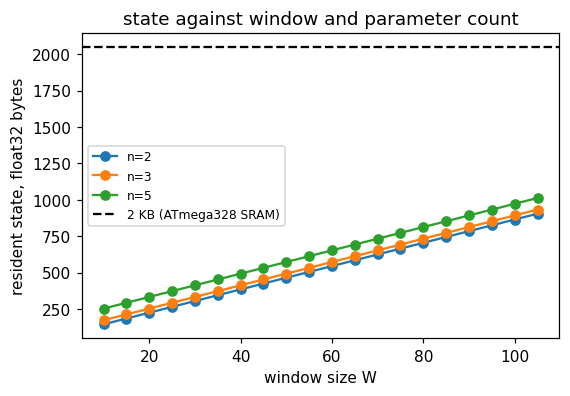

In [14]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for n, vals in sweep.items():
    ax.plot(Ws, vals, "o-", label=f"n={n}")
ax.axhline(2048, color="k", linestyle="--", label="2 KB (ATmega328 SRAM)")
ax.set_xlabel("window size W")
ax.set_ylabel("resident state, float32 bytes")
ax.legend(fontsize=8)
ax.set_title("state against window and parameter count")
plt.show()

In [15]:
# fails if state does not grow at a constant rate per unit of window
# (linear), for a fixed parameter count
step_w = int(Ws[1] - Ws[0])
for n, vals in sweep.items():
    diffs = np.diff(vals)
    assert np.allclose(diffs, diffs[0]), f"n={n} state is not linear in W"
# fails if state does not grow faster than linearly as parameter count
# grows, for a fixed window (the n^2 covariance term)
w_fixed = int(Ws[0])
by_n = {n: cost.embedded_footprint(n, w_fixed)["sram_bytes_f32"] for n in sweep}
ns = sorted(by_n)
first_gap = by_n[ns[1]] - by_n[ns[0]]
second_gap = by_n[ns[2]] - by_n[ns[1]]
first_rate = first_gap / (ns[1] - ns[0])
second_rate = second_gap / (ns[2] - ns[1])
assert second_rate > first_rate, "state grew linearly, not quadratically, in n"
three_axis_w15 = cost.embedded_footprint(3, 15)["sram_bytes_f32"] * 3
assert three_axis_w15 == 636
print(f"linear in W: +{diffs[0]:.0f} B per {step_w} samples of window, "
      f"at n={list(sweep.keys())[-1]}")
print(f"quadratic in n at W={w_fixed}: gap {ns[0]}->{ns[1]} is {first_gap} B "
      f"({first_rate:.0f} B a unit), gap {ns[1]}->{ns[2]} is {second_gap} B "
      f"({second_rate:.0f} B a unit)")
print(f"a three-axis tracker at W=15 is {three_axis_w15} B")

linear in W: +40 B per 5 samples of window, at n=5
quadratic in n at W=10: gap 2->3 is 28 B (28 B a unit), gap 3->5 is 80 B (40 B a unit)
a three-axis tracker at W=15 is 636 B


In [16]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("24_embedded_footprint", "state_vs_window", state_vs_window)
    print("wrote experiments/results/24_embedded_footprint/state_vs_window.csv")

wrote experiments/results/24_embedded_footprint/state_vs_window.csv


## The MCU fit

`cost.footprint_rows`'s MCU table at the three-axis tracker's own
configuration (n=3, W=15, the CA quadratic of section 1), the tracker's
share of each part's SRAM, and a compute estimate for one 10 Hz epoch of
the same tracker. The share of the same three axes at the damped
oscillator's own W=60 is printed beside it: that configuration is where
the 2 KB part stops having margin, and it carries no check, being a limit
rather than a claim.

The compute estimate is a FLOP count over a datasheet-order MFLOP/s
figure, so it is checked at the one point where a chip was timed: the rig
notebook's on-chip update, one axis of the linear model (n=2, W=15) in
float32 on the nRF52840. The ratio of the measured time to the estimate
for that configuration is then carried to every row.

In [17]:
damped = plants.PLANTS[0]
TRACKER_W = 15
mcu_rows = cost.footprint_rows(lat_by_plant[damped["key"]], n=3, W=TRACKER_W)
track32 = mcu_rows["track32"]
track32_wide = cost.footprint_rows(lat_by_plant[damped["key"]], n=3,
                                   W=damped["window"])["track32"]
mcu_fit = pd.DataFrame(mcu_rows["mcu"])
sram_bytes = mcu_fit.SRAM_KB * 1024
mcu_fit["tracker_B"] = track32
mcu_fit[f"share_W{TRACKER_W}_pct"] = (track32 / sram_bytes * 100).round(1)
mcu_fit[f"share_W{damped['window']}_pct"] = (track32_wide / sram_bytes
                                             * 100).round(1)
mcu_fit

,MCU,SRAM_KB,clock_MHz,FPU,MFLOPs,fits,tracker_B,share_W15_pct,share_W60_pct
0,AVR ATmega328 (Uno),2,16,no (soft),0.05,yes,636,31.1,83.8
1,ARM Cortex-M0+ (SAMD21),32,48,no (soft),0.30,yes,636,1.9,5.2
2,ARM Cortex-M4F (STM32F4),192,168,yes,30.00,yes,636,0.3,0.9
3,ESP32 (LX6 FPU),520,240,yes,40.00,yes,636,0.1,0.3
4,nRF52840,256,64,yes,10.00,yes,636,0.2,0.7


In [18]:
EPOCH_BUDGET_MS = 100.0  # 10 Hz
tracker_flops = 3 * approx_flops_per_update(3, 15)  # three axes, one CA quadratic each
compute_rows = []
for name, sram_bytes, clock_mhz, fpu, mflops in cost.MCUS:
    time_ms = tracker_flops / (mflops * 1e6) * 1000.0
    compute_rows.append({"MCU": name, "MFLOPs": mflops, "epoch_ms": time_ms,
                          "under_budget": time_ms < EPOCH_BUDGET_MS})
compute_estimate = pd.DataFrame(compute_rows)
compute_estimate

,MCU,MFLOPs,epoch_ms,under_budget
0,AVR ATmega328 (Uno),0.05,31.620000,True
1,ARM Cortex-M0+ (SAMD21),0.30,5.270000,True
2,ARM Cortex-M4F (STM32F4),30.00,0.052700,True
3,ESP32 (LX6 FPU),40.00,0.039525,True
4,nRF52840,10.00,0.158100,True


In [19]:
RIG_UPDATE_US = 104.32  # rig notebook, results/rig/onchip_cost.csv: mean on-chip update
rig_mflops = dict((name, mflops) for name, _, _, _, mflops in cost.MCUS)["nRF52840"]
rig_estimate_us = approx_flops_per_update(2, 15) / (rig_mflops * 1e6) * 1e6
estimate_error = RIG_UPDATE_US / rig_estimate_us
compute_estimate["epoch_ms_scaled"] = compute_estimate.epoch_ms * estimate_error
compute_estimate["scaled_under_budget"] = (compute_estimate.epoch_ms_scaled
                                           < EPOCH_BUDGET_MS)
print(f"nRF52840, n=2, W=15: estimate {rig_estimate_us:.1f} us, measured "
      f"{RIG_UPDATE_US:.1f} us, the estimate is {estimate_error:.1f}x low")
compute_estimate

nRF52840, n=2, W=15: estimate 29.8 us, measured 104.3 us, the estimate is 3.5x low


,MCU,MFLOPs,epoch_ms,under_budget,epoch_ms_scaled,scaled_under_budget
0,AVR ATmega328 (Uno),0.05,31.620000,True,110.691221,False
1,ARM Cortex-M0+ (SAMD21),0.30,5.270000,True,18.448537,True
2,ARM Cortex-M4F (STM32F4),30.00,0.052700,True,0.184485,True
3,ESP32 (LX6 FPU),40.00,0.039525,True,0.138364,True
4,nRF52840,10.00,0.158100,True,0.553456,True


In [20]:
by_mcu_sram = {row["MCU"]: row["SRAM_KB"] * 1024 for row in mcu_rows["mcu"]}
# fails if the three-axis tracker at its own W=15 does not sit under half
# the SRAM of every named part
for name, sram in by_mcu_sram.items():
    assert track32 < sram * 0.5, name
# fails if the raw compute estimate crosses the epoch budget anywhere,
# softest float included
assert compute_estimate.under_budget.all()
# fails if a 32-bit part crosses the budget once the estimate carries the
# error measured on the rig's chip
wide = ~compute_estimate.MCU.str.startswith("AVR")
assert compute_estimate.scaled_under_budget[wide].all()
worst = compute_estimate.loc[compute_estimate.epoch_ms.idxmax()]
tightest = min(by_mcu_sram, key=by_mcu_sram.get)
print(f"three-axis tracker at W={TRACKER_W}: {track32} B, "
      f"{track32 / by_mcu_sram[tightest] * 100:.0f} percent of the "
      f"{tightest}; the same axes at W={damped['window']}: {track32_wide} B, "
      f"{track32_wide / by_mcu_sram[tightest] * 100:.0f} percent")
print(f"softest-float estimate {worst.epoch_ms:.1f} ms on {worst.MCU} "
      f"against a {EPOCH_BUDGET_MS:.0f} ms budget, "
      f"{worst.epoch_ms_scaled:.1f} ms scaled")

three-axis tracker at W=15: 636 B, 31 percent of the AVR ATmega328 (Uno); the same axes at W=60: 1716 B, 84 percent
softest-float estimate 31.6 ms on AVR ATmega328 (Uno) against a 100 ms budget, 110.7 ms scaled


In [21]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("24_embedded_footprint", "mcu_fit", mcu_fit)
    notebook.save_table("24_embedded_footprint", "compute_estimate", compute_estimate)
    print("wrote experiments/results/24_embedded_footprint/mcu_fit.csv, "
          "compute_estimate.csv")

wrote experiments/results/24_embedded_footprint/mcu_fit.csv, compute_estimate.csv


## Findings and limits

The struct model matches every configuration exactly: 212 B (f32) / 424 B
(f64) for the CA-quadratic GPS axis (n=3, W=15), 492 / 984 B for the
damped-sine control loop (n=3, W=50), 224 / 448 B for the linear range
smoother (n=2, W=20). A live block filter's resident window (length 60),
covariance shape (3, 3) and tracked parameter set are identical after 100
samples and after 10,000: the state is fixed by the window and the
parameter count, not by how long the stream has run.

The model's 184 B for the rig's own configuration (n=2, W=15) sits 32 B
above the flashed struct's measured 152 B, and both parts of that gap are
named: 8 B is the scratch the model counts alongside the estimate and the
sketch keeps on the stack rather than in the struct, and 24 B is six of
the eight bookkeeping words the model allows for and this sketch does not
use. Nothing is left over.

At each plant's own window, the streaming filters cost 72 to 98
microseconds a median step (block and Legendre, across the four plants),
the EKF 8.8 to 12.3, RLS 4.6. The sliding-window refit's median
step is a fifth of a microsecond, which is not its cost: it fits once in
twenty steps and only appends and pops on the other nineteen, so the
median is by construction a step that does no fitting. Its cost a step is
the mean over the drive, 29 to 121 microseconds depending on the plant
(121 on the damped oscillator, where the bounded solver works hardest).
Charged that way the naive refit is the same order as a filter step, and
on the damped oscillator the most expensive of the five. What separates
the two is the worst step: a filter's is 0.2 to 0.3 milliseconds on every
plant, the refit's 0.9 to 15, and a device that must answer every sample
budgets for the worst step. The refit also needs an iterative optimizer
on the device, the filter a fixed struct and a fixed update.

At the rig's own rate (0.03 s, 33 Hz) and a 3-parameter CA quadratic at
W=15, the block filter costs 72.1 microseconds a step, Legendre 72.1, and
an isolated unconstrained refit call 50.4, so a single refit call is about
0.7 of a block-filter step. The plain Kalman-CA is 8.4 microseconds on
one axis against the filter's 72.1, about 9x cheaper per axis, and 24.3
microseconds on the three axes sections 4 and 5 size against about 216
for three one-axis filter steps. It carries no window and fits no
nonlinear model: the filter tracks the parameters of a model, the Kalman
a position and its derivatives, and where a position is all that is
wanted the Kalman is the cheaper tool.

State grows by 8 bytes per sample of window at every parameter count
tried (40 B over a 5-sample step at n=5, the same constant at n=2 and
n=3), and by more per unit of parameter count as the count grows (28 B a
unit from n=2 to n=3, 40 B a unit from n=3 to n=5): linear in the window,
faster than linear in the parameter count, as
the covariance term predicts. A three-axis CA-quadratic tracker at W=15 is
636 bytes.

That tracker is 31 percent of the 2 KB ATmega328's SRAM and under 2
percent of the Cortex-M0+, the Cortex-M4F, the ESP32 and the nRF52840:
under half of every part, which is the claim. The window is what decides
that: the same three axes at the damped oscillator's W=60 are 1,716
bytes, 84 percent of the ATmega328, a fit with no margin left, while they
stay under 6 percent of every other part.

The compute estimate for one 10 Hz epoch of the three-axis tracker (at
W=15) is 31.6 ms on the ATmega328 against a 100 ms budget, and 5.3 ms or
less on every other part. At the one point where a chip was timed, the
rig's nRF52840 running one axis of the linear model at W=15, the estimate
is 29.8 microseconds and the measured update 104.3: the FLOP count over a
datasheet rate is 3.5x low there. Carried to every row, that error leaves
the 32-bit parts under the budget (18.4 ms on the Cortex-M0+, under a
millisecond on the three with an FPU) and puts the ATmega328 at 110.7 ms,
over a 10 Hz epoch. The 8-bit part is a fit in bytes and, on this
estimate, not in time at 10 Hz; no 8-bit chip was timed.

Limits: every microsecond here is a desktop Python reference for the
algorithm's shape, not a prediction of MCU timing (NumPy does not run on
an AVR). Everything ran on one machine, which the workstation shares with
other work, so a rerun's numbers will move within the spread printed
beside each median, and a mean or a worst step moves further than that.
The compute estimate is for one epoch rate (10 Hz) only, its MFLOP/s
figures are order-of-magnitude, and its error is measured on one chip with
an FPU and carried to parts without one. Notebook 21 has the
filter's own tuning and its cost on its native jobs; the rig notebook
(`packages/dtfit-hardware`) has the measured chip this section's model is
checked against.

In [22]:
print(notebook.provenance(STARTED))

2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 6.2s
